In [ ]:
from src import gemma
from PIL import Image  # Import for image processing
import torch
model, processor = gemma.get_gemma("google/gemma-3-4b-it")


In [ ]:
import torch
image = Image.open("./img.jpg")  # Load the raw image

input_text = [
    {
        "role": "system",
        "content": [{"type": "text",
                     "text": "You are a helpful assistant."}]
    },
    {
        "role": "user",
        "content": [
            {"type": "image", "image": image},
            {"type": "text", "text": f"How many tanks are in this image. Think step by step, but the very last word you say must be the exact number and nothing else and no punctuation, not even a period."}
        ]
    }
]

inputs = processor.apply_chat_template(
    input_text, add_generation_prompt=True, tokenize=True,
    return_dict=True, return_tensors="pt"
).to(model.device, dtype=torch.bfloat16)

input_len = inputs["input_ids"].shape[-1]

with torch.inference_mode():
    generation = model.generate(**inputs, max_new_tokens=1000, do_sample=True, use_cache=False, coconut=.2, progress_bar=True, processor=processor) # , print_similarity_scores=True, processor=processor)
    text_generation = generation[0][input_len:]

decoded = processor.decode(text_generation, skip_special_tokens=True)
# print(generation)
print('decoded:', decoded)



In [ ]:
import pandas as pd
import io
from PIL import Image
import numpy as np

df = pd.read_parquet('./dataset', engine='pyarrow')#change path here

example = df.iloc[10]
images = [Image.open(io.BytesIO(im_bytes)) for im_bytes in example['image_bytes']]

import matplotlib.pyplot as plt

# Display images
fig, axes = plt.subplots(1, len(images), figsize=(15, 5))

if len(images) == 1:
    axes.imshow(images[0])
    axes.axis("off")
else:
    for ax, img in zip(axes, images):
        ax.imshow(img)
        ax.axis("off")

plt.show()

question = example['question']
print(question)
answer_choices = example['answers']
print(answer_choices)
correct_answer = example['correct_answer']
print(correct_answer)

# # Function to convert bytes to BytesIO objects
# def convert_to_bytesio(image_bytes):
#     return np.asarray([Image.open(io.BytesIO(im_bytes)) for im_bytes in image_bytes][0], dtype=np.uint8)
#
#     # if isinstance(image_bytes, ):
#     #     # If it's a list of images, convert each image
#     #     return [Image.open(io.BytesIO(im_bytes)) for im_bytes in image_bytes]
#     # else:
#     #     print(type(image_bytes))
#     #     # If it's a single image
#     #     return Image.open(io.BytesIO(image_bytes))
#
#
# # Apply the conversion to the entire column
# df['image_bytes'] = df['image_bytes'].apply(convert_to_bytesio)


In [24]:
import json
from tqdm import tqdm
import re
import torch
def extract_ans(pred_text):
    matches = re.findall(r"\[(.*?)\]", pred_text)
    
    return matches

def predict_all(dataset, processor, model, coconut=False):
    predictions = []
    n_correct = 0
    for i in (pbar := tqdm(range(len(dataset['image_bytes'])), postfix={'correct': 'n/a', 'prediction': 'n/a',})):
        input_images = [Image.open(io.BytesIO(im_bytes)) for im_bytes in dataset['image_bytes'].iloc[i]][::-1]
        question = dataset['question'].iloc[i]
        answer_choices = dataset['answers'].iloc[i]

        input_prompt = f'''
                        Instructions: You have to answer the following question using the given options.
                                      Enclose your answer in [].
                                      For example, if the answer is yes, it must be formatted like [yes].

                        Question: {question}

                        Your answer must be one the options given below. Enclose the answer in brackets like [answer].
                        Options: {answer_choices}                        
                
                       '''
        input_text = [
                {
                    "role": "system",
                    "content": [{"type": "text",
                                 "text": "You are a helpful assistant. Be sure to explain your reasoning as briefly as possible."}]
                },
                {
                    "role": "user",

                    "content": [{'type': 'image', 'image': img} for img in input_images] + \
                               [{"type": "text", "text": input_prompt}, ]
                }
            ]
        inputs = processor.apply_chat_template(
                input_text, add_generation_prompt=True, tokenize=True,
                return_dict=True, return_tensors="pt"
            ).to(model.device, dtype=torch.bfloat16)

        input_len = inputs["input_ids"].shape[-1]

        with torch.inference_mode():
            generation = model.generate(**inputs, max_new_tokens=500, use_cache=not coconut, coconut=coconut)
            text_generation = generation[0][input_len:]
    
        decoded = processor.decode(text_generation, skip_special_tokens=True)
        prediction = extract_ans(decoded)
        predictions.append({
            "question": question,
            "answers": answer_choices,
            "pred_text": decoded,
            "prediction": prediction,
            "correct_answer": dataset['correct_answer'].iloc[i]
        })
        correct='False'
        try:
            if len(prediction) == 1:
                if prediction[0] == dataset['correct_answer'].iloc[i]:
                    n_correct += 1
                    correct='True'
            
            pbar.set_postfix(correct=correct, prediction=f"{prediction}/{dataset['correct_answer'].iloc[i]}")

        except:
            pbar.set_postfix(correct=correct, prediction=f"Error: {prediction}/{dataset['correct_answer'].iloc[i]}")
        if correct == 'False':
            fig, axes = plt.subplots(1, len(input_images), figsize=(15, 5))

            # Handle both single and multiple image cases
            if len(input_images) == 1:
                axes.imshow(input_images[0])
                axes.axis("off")
            else:
                for ax, img in zip(axes, input_images):
                    ax.imshow(img)
                    ax.axis("off")

            plt.show()

            # Pretty print the prediction structure with indentation
            if predictions:
                display(predictions[-1], indent=4)

        pbar.set_description(f'{n_correct} correct({n_correct * 100.0 / (i + 1.0) :0.2f}%)')
        # pbar.set_postfix(f"{predictions[-1]['answers']}/{predictions[-1]['correct_answer']}: {predictions[-1]['pred_text']}")
        # print(f"Question: {question}")
        # print(f"Choices: {answer_choices}")
        # print(f"Predicted Answer: {prediction}")
        # print(f"Correct Answer: {dataset['correct_answer'][i]}")
        # print("-" * 50)

    return predictions

# tmp = predict_all(df, processor, model, coconut=None)

Testing:  0.050


  0%|          | 0/40 [02:09<?, ?it/s, correct=False, prediction=['right by 16 degrees']/left by 16 degrees]

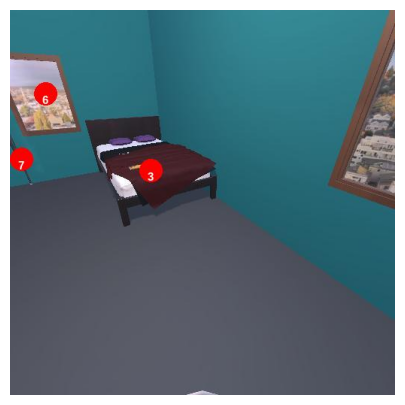

  0%|          | 0/40 [02:09<?, ?it/s, correct=False, prediction=['right by 16 degrees']/left by 16 degrees]


TypeError: ZMQDisplayPublisher.publish() got an unexpected keyword argument 'indent'

In [25]:
coconut_predictions = {}
df_sample = df.sample(frac=0.01, random_state=42)
for gamma in np.geomspace(0.05, 0.4, num=10):
    print(f'Testing: {gamma: .3f}')
    coconut_predictions[gamma] = predict_all(df_sample, processor, model, coconut=gamma)
coconut_predictions[0] = predict_all(df, processor, model, coconut=None)


In [ ]:
import pickle

with open("coconut_predictions.pkl", "wb") as file:
    pickle.dump(coconut_predictions, file)


In [ ]:
from src import gemma
model, processor = gemma.get_gemma("./noah working/google/gemma-3-27b-it")


In [ ]:
better_base_predictions = predict_all(df, processor, model, coconut=False)
better_coconut_predictions = predict_all(df, processor, model, coconut=True)